In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/0664.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/3863.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/2008.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/0106.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/3417.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/5705.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/5307.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/1700.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/3501.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/5333.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/2628.jpg
/kaggle/input/glaucoma-classification-datasets/LAG/LAG/Training/glaucoma/4009.jpg
/kaggle/input/gl

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ----------------------------
# 1. Define data directory
# ----------------------------
data_dir = "/kaggle/input/glaucoma-classification-datasets/ACRIMA/ACRIMA/NOT PARTITIONED"

# ----------------------------
# 2. Define transforms
# ----------------------------
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----------------------------
# 3. Load full dataset
# ----------------------------
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)
total_size = len(full_dataset)

# ----------------------------
# 4. Split: 80% train, 20% test
# ----------------------------
train_size = int(0.8 * total_size)
test_size = total_size - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)

# ----------------------------
# 5. Further split training into train + val (10% of train → val)
# ----------------------------
val_size = int(0.1 * train_size)
train_size = train_size - val_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Total: {total_size}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ----------------------------
# 6. DataLoaders
# ----------------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# 7. Number of classes
# ----------------------------
num_classes = len(full_dataset.classes)
print(f"Number of classes: {num_classes}")

Total: 705
Train: 508, Val: 56, Test: 141
Number of classes: 2


In [16]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter

# ----------------------------
# 1. Define custom transform for Gaussian noise
# ----------------------------
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        noisy_tensor = tensor + noise
        noisy_tensor = torch.clamp(noisy_tensor, 0., 1.)
        return noisy_tensor

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean}, std={self.std})'

# ----------------------------
# 2. Define data directory
# ----------------------------
data_dir = "/kaggle/input/glaucoma-classification-datasets/ACRIMA/ACRIMA/NOT PARTITIONED"

# ----------------------------
# 3. Define transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.03),   # Gaussian noise
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.03),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ----------------------------
# 4. Load full dataset
# ----------------------------
full_dataset = datasets.ImageFolder(data_dir, transform=test_val_transform)
total_size = len(full_dataset)

# ----------------------------
# 5. Split: 80% train, 20% test
# ----------------------------
train_size = int(0.8 * total_size)
test_size = total_size - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)

# ----------------------------
# 6. Further split training into train + val (10% of train → val)
# ----------------------------
val_size = int(0.1 * train_size)
train_size = train_size - val_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size], generator=generator)

# Apply noise + blur augmentations only on training set
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_val_transform
test_dataset.dataset.transform = test_val_transform

print(f"Total: {total_size}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# ----------------------------
# 7. DataLoaders
# ----------------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# 8. Number of classes
# ----------------------------
num_classes = len(full_dataset.classes)
print(f"Number of classes: {num_classes}")

Total: 705
Train: 508, Val: 56, Test: 141
Number of classes: 2


In [17]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define datasets
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

generator = torch.Generator().manual_seed(42)

# Split dataset into training and test sets
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size],generator = generator )

# Define data loaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define number of classes
num_classes = len(full_dataset.classes)
print(train_size)
print(test_size)

564
141


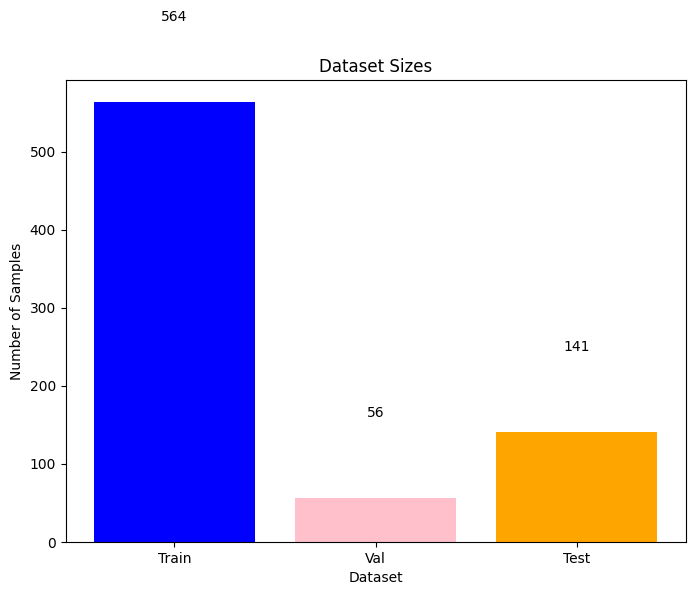

Class Names: ['glaucoma', 'normal']


In [18]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
# Get class names
class_names = full_dataset.classes

# Create bar plot
dataset_sizes = [train_size, val_size, test_size]
dataset_labels = ['Train', 'Val', 'Test']

plt.figure(figsize=(8, 6))
plt.bar(dataset_labels, dataset_sizes, color=['blue','pink','orange'])
plt.title('Dataset Sizes')
plt.xlabel('Dataset')
plt.ylabel('Number of Samples')

# Add text labels on top of bars
for i, size in enumerate(dataset_sizes):
    plt.text(i, size + 100, str(size), ha='center', va='bottom')

plt.show()

# Print class names
print("Class Names:", class_names)

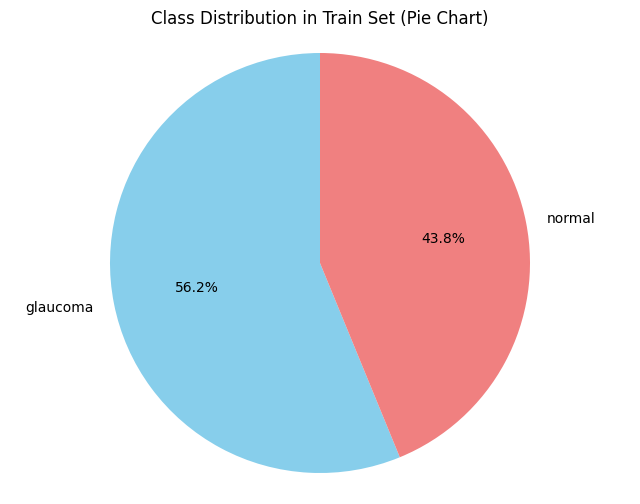

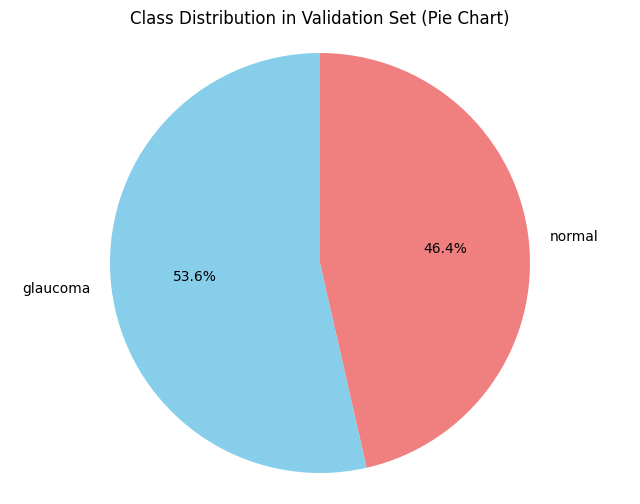

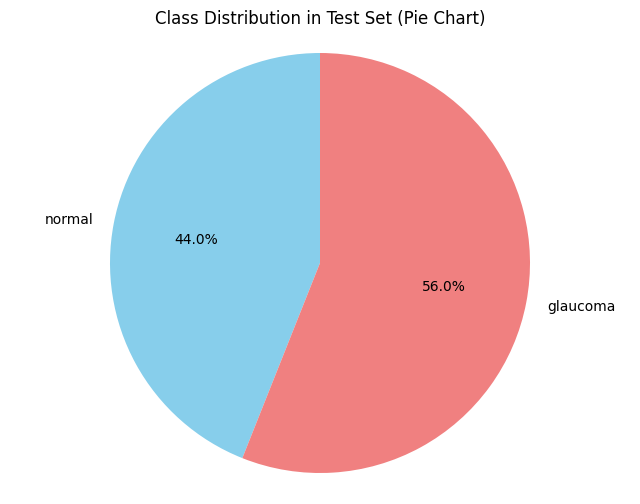

In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np



# Get class names
class_names = full_dataset.classes

def plot_class_distribution_pie(dataset, dataset_name):
    class_counts = {}
    for _, label in dataset:
        class_name = class_names[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    # Define colors for each class (customize as needed)
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 
          'gold', 'mediumorchid', 'lightseagreen', 'chocolate'] 
    num_classes = len(class_names)

    plt.figure(figsize=(8, 6))
    plt.pie(class_counts.values(), labels=class_counts.keys(), 
            autopct='%1.1f%%', startangle=90, colors=colors[:num_classes])
    plt.title(f'Class Distribution in {dataset_name} Set (Pie Chart)')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Plot class distribution for each dataset using pie charts
plot_class_distribution_pie(train_dataset, 'Train')
plot_class_distribution_pie(val_dataset, 'Validation')
plot_class_distribution_pie(test_dataset, 'Test')

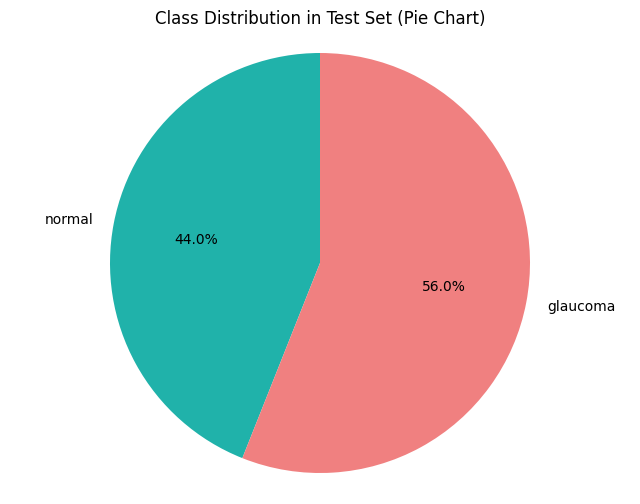

In [20]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np



# Get class names
class_names = full_dataset.classes

def plot_class_distribution_pie(dataset, dataset_name):
    class_counts = {}
    for _, label in dataset:
        class_name = class_names[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

    # Define colors for each class (customize as needed)
    colors = ['lightseagreen','lightcoral', 'lightgreen', 'orange', 'skyblue',
          'gold', 'mediumorchid'] 
    num_classes = len(class_names)

    plt.figure(figsize=(8, 6))
    plt.pie(class_counts.values(), labels=class_counts.keys(), 
            autopct='%1.1f%%', startangle=90, colors=colors[:num_classes])
    plt.title(f'Class Distribution in {dataset_name} Set (Pie Chart)')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Plot class distribution for each dataset using pie charts

plot_class_distribution_pie(test_dataset, 'Test')

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import math
import matplotlib.pyplot as plt 


# KANLinear definition Soure: https://github.com/Blealtan/efficient-kan/blob/f39e5146af34299ad3a581d2106eb667ba0fa6fa/src/efficient_kan/kan.py#L6
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.dim() == 2 and x.size(1) == self.in_features

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        """
        Compute the regularization loss.

        This is a dumb simulation of the original L1 regularization as stated in the
        paper, since the original one requires computing absolutes and entropy from the
        expanded (batch, in_features, out_features) intermediate tensor, which is hidden
        behind the F.linear function if we want an memory efficient implementation.

        The L1 regularization is now computed as mean absolute value of the spline
        weights. The authors implementation also includes this term in addition to the
        sample-based regularization.
        """
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )

In [22]:
# Define the KAN convolutional layer
class KAN_Convolutional_Layer(torch.nn.Module):
    def __init__(
            self,
            convs,
            n_convs: int = 1,
            kernel_size: tuple = (2,2),
            stride: tuple = (1,1),
            padding: tuple = (0,0),
            dilation: tuple = (1,1),
            grid_size: int = 5,
            spline_order: int = 3,
            scale_noise: float = 0.1,
            scale_base: float = 1.0,
            scale_spline: float = 1.0,
            base_activation=torch.nn.SiLU,
            grid_eps: float = 0.02,
            grid_range: tuple = (-1, 1)
    ):
        super(KAN_Convolutional_Layer, self).__init__()
        self.convs = nn.ModuleList(convs)  # Store convolutional layers
        self.n_convs = len(convs)
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.kernel_size = kernel_size  # Store kernel_size
        self.stride = stride  # Store stride
        self.padding = padding  # Store padding
        self.dilation = dilation 
        self.device = device
        self.convs = nn.ModuleList([KAN_Convolution(
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
            grid_size=grid_size,
            spline_order=spline_order,
            scale_noise=scale_noise,
            scale_base=scale_base,
            scale_spline=scale_spline,
            base_activation=base_activation,
            grid_eps=grid_eps,
            grid_range=grid_range
        ) for _ in range(n_convs)])

    def forward(self, x: torch.Tensor, update_grid=False):
        if self.n_convs > 1:
            return self.multiple_convs_kan_conv2d(x, self.convs,self.kernel_size,self.stride,self.dilation,self.padding,self.device)
        return self.convs[0].forward(x)

    def multiple_convs_kan_conv2d(self, x: torch.Tensor, convs, kernel_size, stride, dilation, padding, device):
        for conv in convs:
            x = conv(x)
            x = torch.nn.SiLU(x)  # Applying ReLU activation function
        return x

In [23]:
import torch.optim as optim
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# Define the KANConvolution layer
class KAN_Convolution(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=(3, 3),
        stride=(1, 1),
        padding=(0, 0),
        dilation=(1, 1),
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=(-1, 1)
    ):
        super(KAN_Convolution, self).__init__()
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.stride = stride
        self.padding = padding
        self.base_activation=base_activation,
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            #base_activation=base_activation,
            dilation=dilation
        )
    
    def forward(self, x):
        #print("Input shape:", x.shape)
        return self.kan_conv2d(x, self.conv, self.kernel_size, self.stride, self.dilation, self.padding)
    
    def kan_conv2d(self, x, conv, kernel_size, stride, dilation, padding):
        batch_size, _, in_height, in_width = x.shape
        out_height = int((in_height - kernel_size[0] + 2 * padding[0]) / stride[0]) + 1
        out_width = int((in_width - kernel_size[1] + 2 * padding[1]) / stride[1]) + 1
        unfolded = F.unfold(x, kernel_size, dilation=dilation, padding=padding, stride=stride)
        unfolded = unfolded.view(batch_size, -1, out_height, out_width, kernel_size[0], kernel_size[1])
        unfolded = unfolded.permute(0, 2, 3, 1, 4, 5).contiguous().view(batch_size * out_height * out_width, -1, kernel_size[0], kernel_size[1])
        conv_out = conv(unfolded)
        return conv_out.view(batch_size, out_height, out_width, -1).permute(0, 3, 1, 2)

In [24]:
# Define the CKAN_Multi_Classification model
class CKAN_Multi_Classification(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CKAN_Multi_Classification, self).__init__()
        self.conv1 = KAN_Convolution(
            in_channels=in_channels,
            out_channels=16,
            kernel_size=(3, 3)
        )

        self.bn1 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = KAN_Convolution(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        #self.kan1 = KANLinear(32 * 54 * 54, num_classes) for kan linear
        self.fc1 = nn.Linear(32 * 54 * 54, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

       

        x = torch.flatten(x, 1)
        
        x = self.fc1(x)
       # x = F.log_softmax(x, dim=1)
        return x

Epoch 1/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.11it/s]


Epoch [1/50], Train Loss: 14.7613, Validation Loss: 4.2829
Train Accuracy: 0.7465, Validation Accuracy: 0.8214
Train Precision: 0.7429, Recall: 0.7396, F1: 0.7408
Validation Precision: 0.8750, Recall: 0.8077, F1: 0.8095


Epoch 2/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.33it/s]


Epoch [2/50], Train Loss: 2.5981, Validation Loss: 0.8953
Train Accuracy: 0.8972, Validation Accuracy: 0.8929
Train Precision: 0.8948, Recall: 0.8978, F1: 0.8960
Validation Precision: 0.8923, Recall: 0.8923, F1: 0.8923


Epoch 3/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.42it/s]


...

Epoch [16/50], Train Loss: 0.0382, Validation Loss: 0.0309
Train Accuracy: 0.9929, Validation Accuracy: 0.9821
Train Precision: 0.9933, Recall: 0.9923, F1: 0.9928
Validation Precision: 0.9815, Recall: 0.9833, F1: 0.9821


Epoch 17/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.70it/s]


Epoch [17/50], Train Loss: 0.0887, Validation Loss: 0.1591
Train Accuracy: 0.9858, Validation Accuracy: 0.9821
Train Precision: 0.9852, Recall: 0.9860, F1: 0.9856
Validation Precision: 0.9839, Recall: 0.9808, F1: 0.9820


Epoch 18/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.32it/s]


Epoch [18/50], Train Loss: 0.1901, Validation Loss: 0.0615
Train Accuracy: 0.9858, Validation Accuracy: 0.9821
Train Precision: 0.9860, Recall: 0.9851, F1: 0.9856
Validation Precision: 0.9815, Recall: 0.9833, F1: 0.9821
Early stopping triggered!


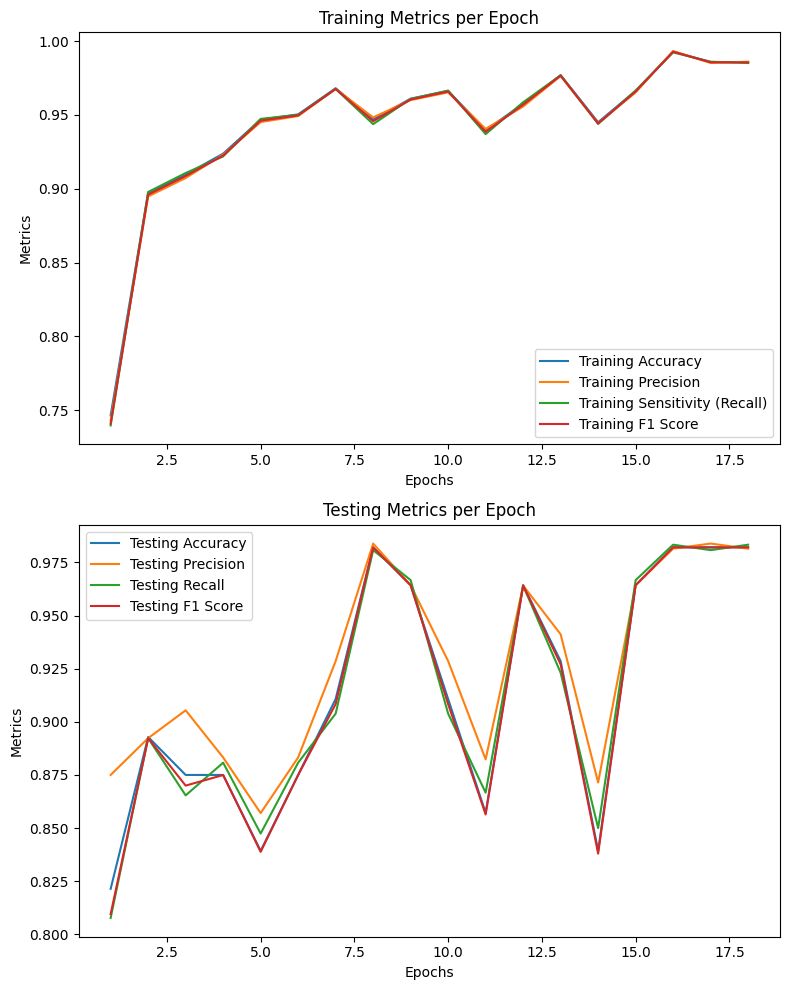

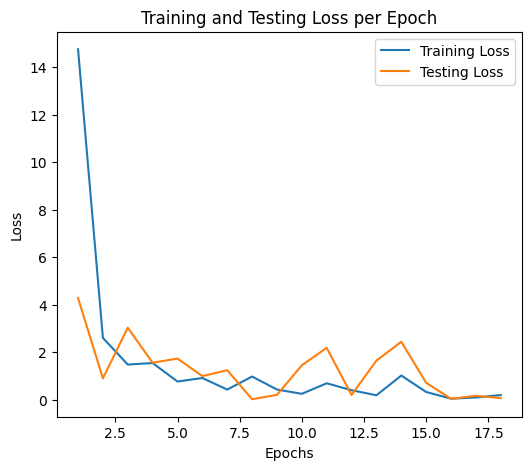

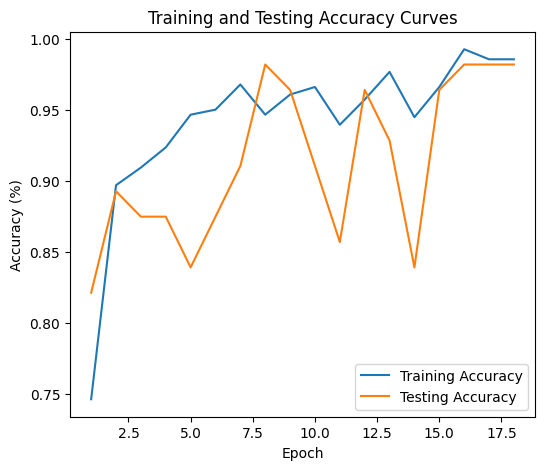

Training time: 211.10 seconds


In [25]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import time

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
#model = KANC_MLP().to(device)          
model = CKAN_Multi_Classification(num_classes=num_classes,in_channels= 3 ).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

start_time = time.time()

# Training loop with early stopping
num_epochs = 50
patience = 10  # Stop if validation loss does not decrease for 5 consecutive epochs
best_val_loss = np.inf
counter = 0

# Lists to store losses and metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Additional metric lists for precision, recall (sensitivity), specificity, and F1
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1s = []
val_f1s = []
train_specificities = []
val_specificities = []

# Function to calculate specificity
#def specificity_score(y_true, y_pred):
 #   cm = confusion_matrix(y_true, y_pred)
  #  tn, fp, fn, tp = cm.ravel()
   # return tn / (tn + fp)

for epoch in range(num_epochs):
    # Training code
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    all_train_preds = []
    all_train_labels = []
    model.train()
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Store predictions and true labels for metrics calculation
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Calculate metrics for training
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy =  correct_train / total_train
    train_precision = precision_score(all_train_labels, all_train_preds, average='macro', zero_division=1)
    train_recall = recall_score(all_train_labels, all_train_preds, average='macro')
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
    #train_specificity = specificity_score(all_train_labels, all_train_preds,average='macro')

    # Store metrics for training
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)
    #train_specificities.append(train_specificity)

    # Validation code
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_val_preds = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Store predictions and true labels for metrics calculation
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    # Calculate metrics for validation
    val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=1)
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro')
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
    #val_specificity = specificity_score(all_val_labels, all_val_preds,average='macro')

    # Store metrics for validation
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    #val_specificities.append(val_specificity)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Plotting the metrics curves
epochs_range = range(1, len(train_losses) + 1)

# Plot metrics for Training
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, train_precisions, label='Training Precision')
plt.plot(epochs_range, train_recalls, label='Training Sensitivity (Recall)')
plt.plot(epochs_range, train_f1s, label='Training F1 Score')
#plt.plot(epochs_range, train_specificities, label='Training Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training Metrics per Epoch')
plt.legend()

# Plot metrics for Validation
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, label='Testing Accuracy')
plt.plot(epochs_range, val_precisions, label='Testing Precision')
plt.plot(epochs_range, val_recalls, label='Testing Recall')
plt.plot(epochs_range, val_f1s, label='Testing F1 Score')
#plt.plot(epochs_range, val_specificities, label='Validation Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Testing Metrics per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Loss curves
plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss per Epoch')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs_range,train_accuracies, label='Training Accuracy')
plt.plot(epochs_range,val_accuracies, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy Curves')
plt.legend()

plt.show()

end_time = time.time()

training_time = end_time - start_time  # Calculate testing time
print(f"Training time: {training_time:.2f} seconds")

<Figure size 1000x800 with 0 Axes>

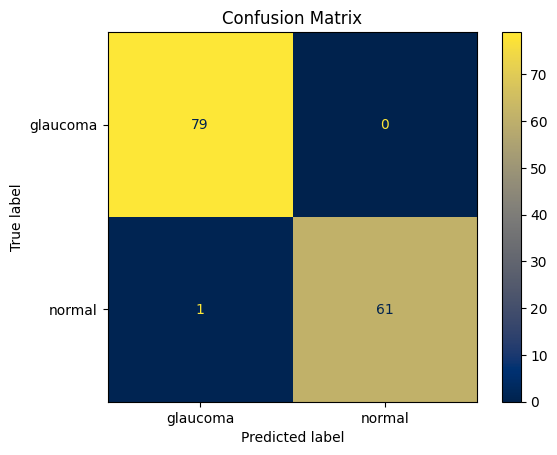

In [26]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Function to get predictions and labels
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    return all_preds, all_labels, all_probs

# Get predictions and labels for the test set
test_preds, test_labels, test_probs = get_predictions_and_labels(model, test_loader, device)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.cividis)
plt.title('Confusion Matrix')
plt.show()

# Binarize the labels for ROC-AUC curve
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

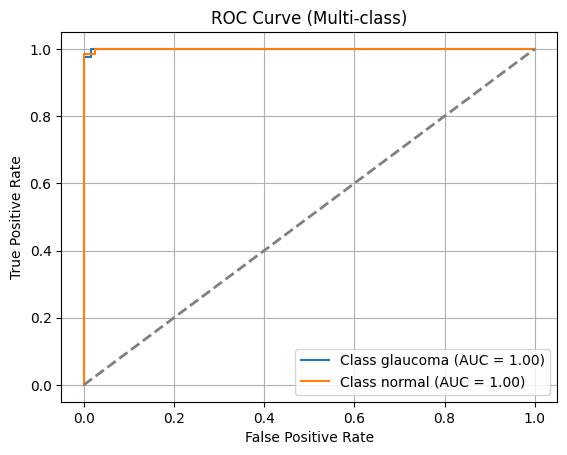

In [27]:
# 12. ROC Curve (Multi-Class)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true = np.eye(num_classes)[test_labels]  # one-hot encode

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i],np.array(test_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ["blue", "green", "red", "orange"]
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
class_names = full_dataset.classes
print(classification_report(test_labels, test_preds, target_names=class_names))

              precision    recall  f1-score   support

    glaucoma       0.99      1.00      0.99        79
      normal       1.00      0.98      0.99        62

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



In [29]:
# Calculate precision, recall, specificity, and accuracy
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

precision = TP / (TP + FP)
specificity = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
F1score = (2*TP) /(2*TP + FP + FN);


# Calculate overall metrics
overall_precision = np.mean(precision)
overall_specificity = np.mean(specificity)
overall_accuracy = np.mean(accuracy)
overall_recall = np.mean(recall)
overall_F1score =np.mean(F1score)

# Binarize the labels for ROC-AUC curve
num_classes = len(full_dataset.classes)
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))


# Print overall metrics
print("Overall Metrics:")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall (Sensitivity): {overall_recall:.4f}")
print(f"  Specificity: {overall_specificity:.4f}")
print(f"  Accuracy: {overall_accuracy:.4f}")
print(f"  F1score: {overall_F1score:.4f}")

Overall Metrics:
  Precision: 0.9938
  Recall (Sensitivity): 0.9919
  Specificity: 0.9919
  Accuracy: 0.9929
  F1score: 0.9928


In [30]:
# Define the CKAN_Multi_Classification model
class CKAN_Multi_Classification(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CKAN_Multi_Classification, self).__init__()
        self.conv1 = KAN_Convolution(
            in_channels=in_channels,
            out_channels=16,
            kernel_size=(3, 3)
        )

        self.bn1 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = KAN_Convolution(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

         # Fully connected layers
        self.fc1 = nn.Linear(32 * 54 * 54, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)
        return x

Epoch 1/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.26it/s]


Epoch [1/50], Train Loss: 12.8760, Validation Loss: 1.2193
Train Accuracy: 0.7163, Validation Accuracy: 0.7857
Train Precision: 0.7119, Recall: 0.7092, F1: 0.7102
Validation Precision: 0.7846, Recall: 0.7846, F1: 0.7846


Epoch 2/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.29it/s]


Epoch [2/50], Train Loss: 0.9806, Validation Loss: 0.8007
Train Accuracy: 0.8936, Validation Accuracy: 0.8929
Train Precision: 0.8929, Recall: 0.8906, F1: 0.8916
Validation Precision: 0.8958, Recall: 0.8897, F1: 0.8916


Epoch 3/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.30it/s]


...

Epoch [16/50], Train Loss: 0.0746, Validation Loss: 0.0635
Train Accuracy: 0.9770, Validation Accuracy: 0.9643
Train Precision: 0.9768, Recall: 0.9764, F1: 0.9766
Validation Precision: 0.9688, Recall: 0.9615, F1: 0.9639


Epoch 17/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.08it/s]


Epoch [17/50], Train Loss: 0.0329, Validation Loss: 0.0140
Train Accuracy: 0.9894, Validation Accuracy: 1.0000
Train Precision: 0.9896, Recall: 0.9887, F1: 0.9892
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000


Epoch 18/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.86it/s]


Epoch [18/50], Train Loss: 0.0319, Validation Loss: 0.0088
Train Accuracy: 0.9911, Validation Accuracy: 1.0000
Train Precision: 0.9908, Recall: 0.9912, F1: 0.9910
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Early stopping triggered!


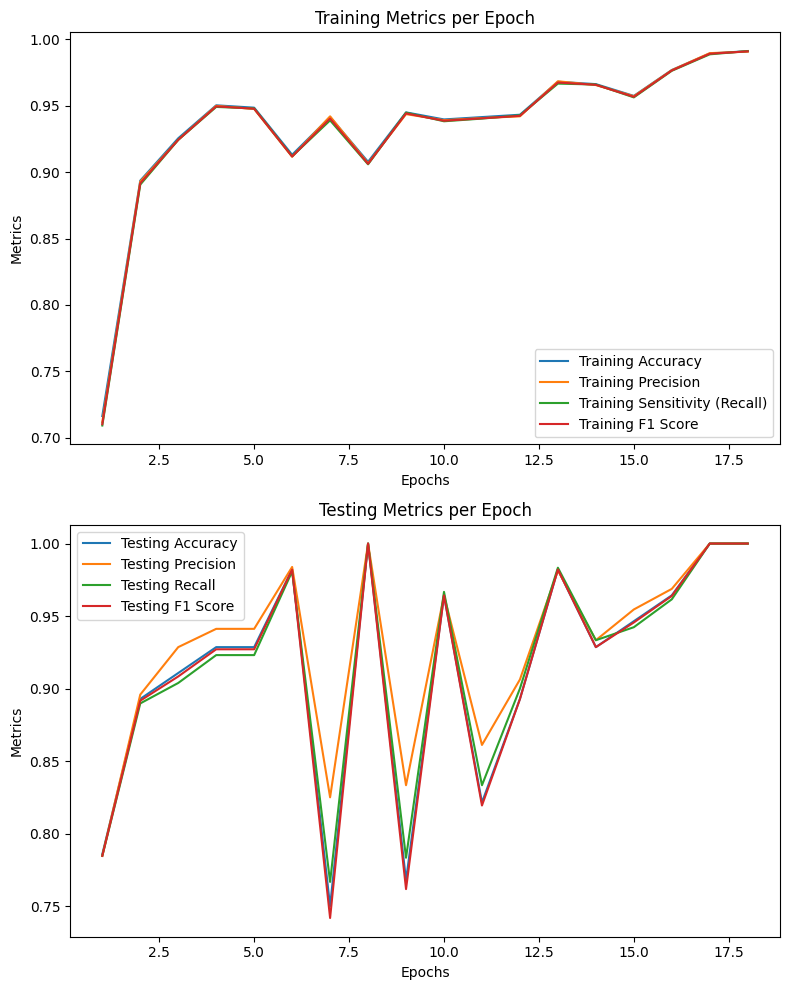

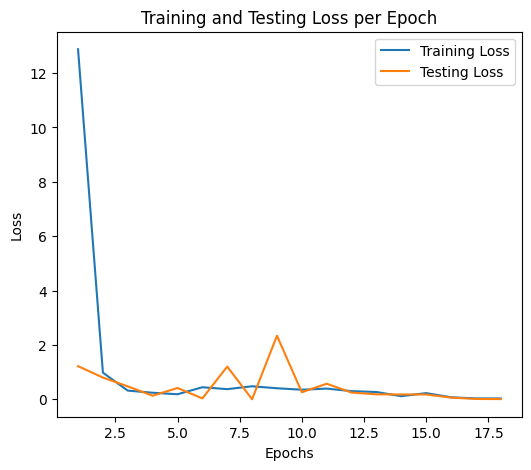

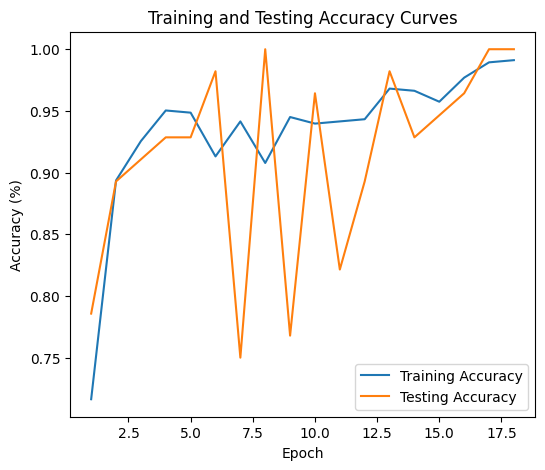

Training time: 212.33 seconds


In [31]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import time

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
#model = KANC_MLP().to(device)          
model = CKAN_Multi_Classification(num_classes=num_classes,in_channels= 3 ).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

start_time = time.time()

# Training loop with early stopping
num_epochs = 50
patience = 10  # Stop if validation loss does not decrease for 5 consecutive epochs
best_val_loss = np.inf
counter = 0

# Lists to store losses and metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Additional metric lists for precision, recall (sensitivity), specificity, and F1
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1s = []
val_f1s = []
train_specificities = []
val_specificities = []

# Function to calculate specificity
#def specificity_score(y_true, y_pred):
 #   cm = confusion_matrix(y_true, y_pred)
  #  tn, fp, fn, tp = cm.ravel()
   # return tn / (tn + fp)

for epoch in range(num_epochs):
    # Training code
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    all_train_preds = []
    all_train_labels = []
    model.train()
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Store predictions and true labels for metrics calculation
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Calculate metrics for training
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy =  correct_train / total_train
    train_precision = precision_score(all_train_labels, all_train_preds, average='macro', zero_division=1)
    train_recall = recall_score(all_train_labels, all_train_preds, average='macro')
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
    #train_specificity = specificity_score(all_train_labels, all_train_preds,average='macro')

    # Store metrics for training
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)
    #train_specificities.append(train_specificity)

    # Validation code
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_val_preds = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Store predictions and true labels for metrics calculation
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    # Calculate metrics for validation
    val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=1)
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro')
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
    #val_specificity = specificity_score(all_val_labels, all_val_preds,average='macro')

    # Store metrics for validation
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    #val_specificities.append(val_specificity)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Plotting the metrics curves
epochs_range = range(1, len(train_losses) + 1)

# Plot metrics for Training
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, train_precisions, label='Training Precision')
plt.plot(epochs_range, train_recalls, label='Training Sensitivity (Recall)')
plt.plot(epochs_range, train_f1s, label='Training F1 Score')
#plt.plot(epochs_range, train_specificities, label='Training Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training Metrics per Epoch')
plt.legend()

# Plot metrics for Validation
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, label='Testing Accuracy')
plt.plot(epochs_range, val_precisions, label='Testing Precision')
plt.plot(epochs_range, val_recalls, label='Testing Recall')
plt.plot(epochs_range, val_f1s, label='Testing F1 Score')
#plt.plot(epochs_range, val_specificities, label='Validation Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Testing Metrics per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Loss curves
plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss per Epoch')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs_range,train_accuracies, label='Training Accuracy')
plt.plot(epochs_range,val_accuracies, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy Curves')
plt.legend()

plt.show()

end_time = time.time()

training_time = end_time - start_time  # Calculate testing time
print(f"Training time: {training_time:.2f} seconds")

<Figure size 1000x800 with 0 Axes>

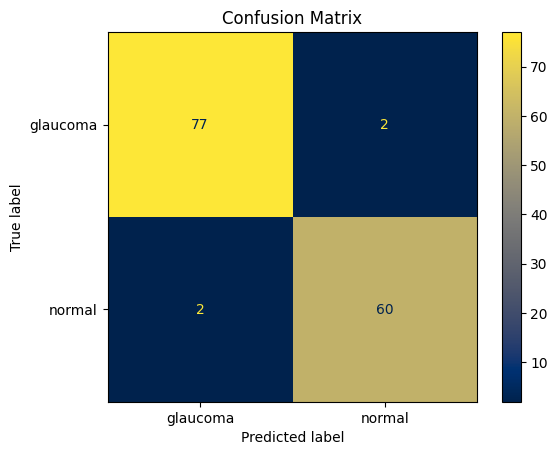

In [32]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Function to get predictions and labels
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    return all_preds, all_labels, all_probs

# Get predictions and labels for the test set
test_preds, test_labels, test_probs = get_predictions_and_labels(model, test_loader, device)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.cividis)
plt.title('Confusion Matrix')
plt.show()

# Binarize the labels for ROC-AUC curve
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

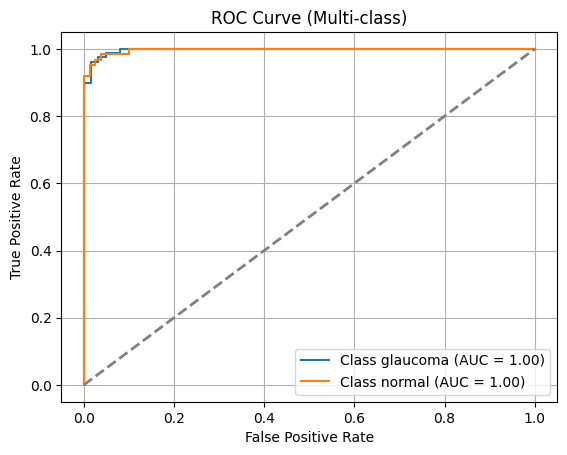

In [33]:
# 12. ROC Curve (Multi-Class)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true = np.eye(num_classes)[test_labels]  # one-hot encode

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i],np.array(test_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ["blue", "green", "red", "orange"]
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [34]:
# Calculate precision, recall, specificity, and accuracy
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

precision = TP / (TP + FP)
specificity = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
F1score = (2*TP) /(2*TP + FP + FN);


# Calculate overall metrics
overall_precision = np.mean(precision)
overall_specificity = np.mean(specificity)
overall_accuracy = np.mean(accuracy)
overall_recall = np.mean(recall)
overall_F1score =np.mean(F1score)

# Binarize the labels for ROC-AUC curve
num_classes = len(full_dataset.classes)
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

# Print overall metrics
print("Overall Metrics:")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall (Sensitivity): {overall_recall:.4f}")
print(f"  Specificity: {overall_specificity:.4f}")
print(f"  Accuracy: {overall_accuracy:.4f}")
print(f"  F1score: {overall_F1score:.4f}")

Overall Metrics:
  Precision: 0.9712
  Recall (Sensitivity): 0.9712
  Specificity: 0.9712
  Accuracy: 0.9716
  F1score: 0.9712


In [35]:
# Define the CKAN_Multi_Classification model
class CKAN_Multi_Classification(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CKAN_Multi_Classification, self).__init__()
        self.conv1 = KAN_Convolution(
            in_channels=in_channels,
            out_channels=16,
            kernel_size=(3, 3)
        )

        self.bn1 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = KAN_Convolution(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.kan1 = KANLinear(32 * 54 * 54, num_classes)
        

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.kan1(x)
        x = F.log_softmax(x, dim=1)
        return x

Epoch 1/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.01it/s]


Epoch [1/50], Train Loss: 9.6104, Validation Loss: 0.5052
Train Accuracy: 0.7181, Validation Accuracy: 0.9286
Train Precision: 0.7144, Recall: 0.7161, F1: 0.7150
Validation Precision: 0.9412, Recall: 0.9231, F1: 0.9271


Epoch 2/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.69it/s]


Epoch [2/50], Train Loss: 1.6921, Validation Loss: 0.0741
Train Accuracy: 0.9238, Validation Accuracy: 0.9821
Train Precision: 0.9224, Recall: 0.9228, F1: 0.9226
Validation Precision: 0.9815, Recall: 0.9833, F1: 0.9821


Epoch 3/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.89it/s]


...

Epoch [17/50], Train Loss: 0.1243, Validation Loss: 0.2222
Train Accuracy: 0.9752, Validation Accuracy: 0.9464
Train Precision: 0.9741, Recall: 0.9757, F1: 0.9748
Validation Precision: 0.9545, Recall: 0.9423, F1: 0.9456


Epoch 18/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.89it/s]


Epoch [18/50], Train Loss: 0.6784, Validation Loss: 0.4389
Train Accuracy: 0.9592, Validation Accuracy: 0.9464
Train Precision: 0.9588, Recall: 0.9584, F1: 0.9586
Validation Precision: 0.9457, Recall: 0.9474, F1: 0.9463


Epoch 19/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.82it/s]


Epoch [19/50], Train Loss: 0.3001, Validation Loss: 0.1115
Train Accuracy: 0.9752, Validation Accuracy: 0.9821
Train Precision: 0.9757, Recall: 0.9739, F1: 0.9747
Validation Precision: 0.9839, Recall: 0.9808, F1: 0.9820
Early stopping triggered!


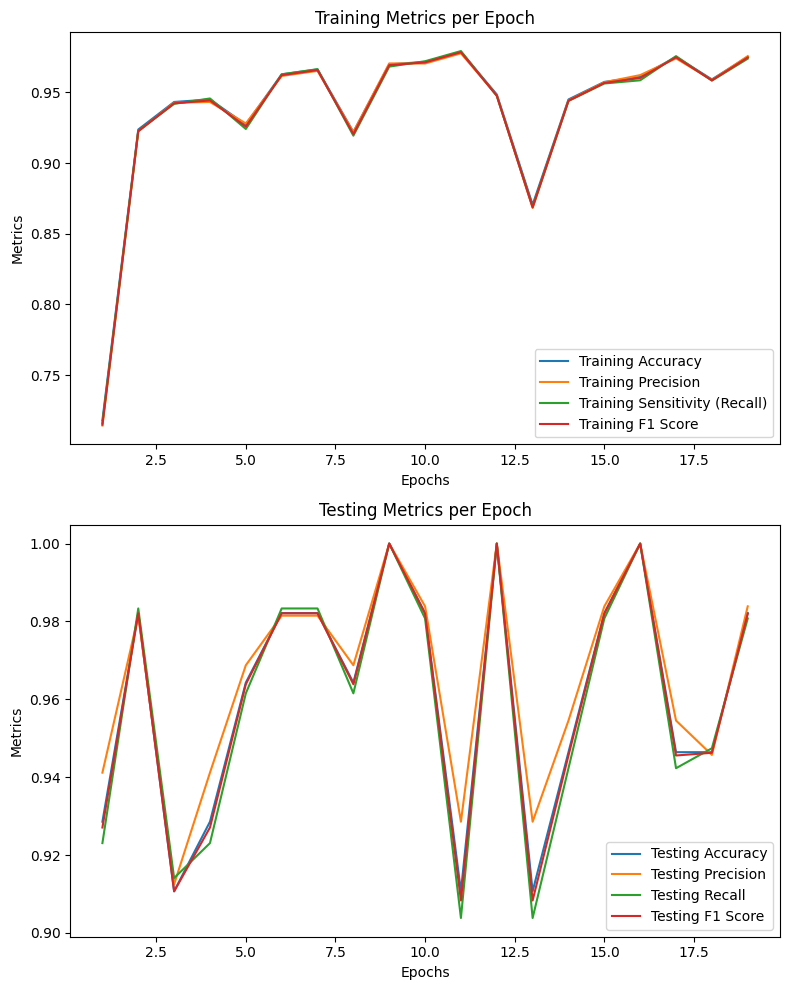

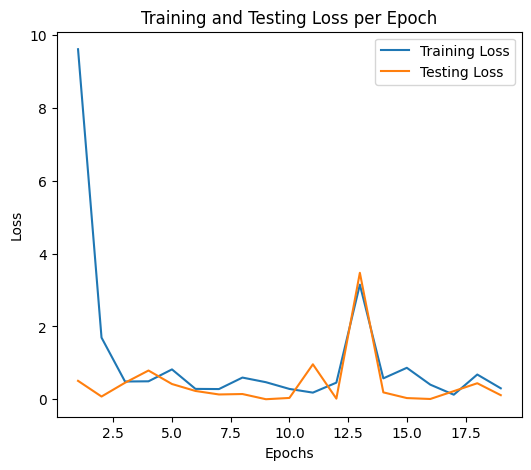

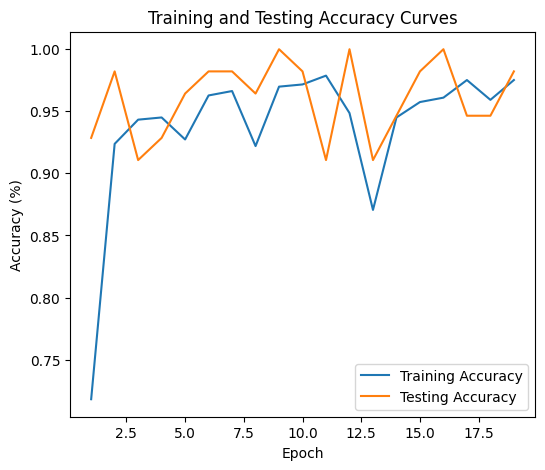

Training time: 238.32 seconds


In [36]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import time

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
#model = KANC_MLP().to(device)          
model = CKAN_Multi_Classification(num_classes=num_classes,in_channels= 3 ).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

start_time = time.time()

# Training loop with early stopping
num_epochs = 50
patience = 10  # Stop if validation loss does not decrease for 5 consecutive epochs
best_val_loss = np.inf
counter = 0

# Lists to store losses and metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Additional metric lists for precision, recall (sensitivity), specificity, and F1
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1s = []
val_f1s = []
train_specificities = []
val_specificities = []

# Function to calculate specificity
#def specificity_score(y_true, y_pred):
 #   cm = confusion_matrix(y_true, y_pred)
  #  tn, fp, fn, tp = cm.ravel()
   # return tn / (tn + fp)

for epoch in range(num_epochs):
    # Training code
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    all_train_preds = []
    all_train_labels = []
    model.train()
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Store predictions and true labels for metrics calculation
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Calculate metrics for training
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy =  correct_train / total_train
    train_precision = precision_score(all_train_labels, all_train_preds, average='macro', zero_division=1)
    train_recall = recall_score(all_train_labels, all_train_preds, average='macro')
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
    #train_specificity = specificity_score(all_train_labels, all_train_preds,average='macro')

    # Store metrics for training
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)
    #train_specificities.append(train_specificity)

    # Validation code
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_val_preds = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Store predictions and true labels for metrics calculation
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    # Calculate metrics for validation
    val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=1)
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro')
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
    #val_specificity = specificity_score(all_val_labels, all_val_preds,average='macro')

    # Store metrics for validation
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    #val_specificities.append(val_specificity)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Plotting the metrics curves
epochs_range = range(1, len(train_losses) + 1)

# Plot metrics for Training
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, train_precisions, label='Training Precision')
plt.plot(epochs_range, train_recalls, label='Training Sensitivity (Recall)')
plt.plot(epochs_range, train_f1s, label='Training F1 Score')
#plt.plot(epochs_range, train_specificities, label='Training Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training Metrics per Epoch')
plt.legend()

# Plot metrics for Validation
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, label='Testing Accuracy')
plt.plot(epochs_range, val_precisions, label='Testing Precision')
plt.plot(epochs_range, val_recalls, label='Testing Recall')
plt.plot(epochs_range, val_f1s, label='Testing F1 Score')
#plt.plot(epochs_range, val_specificities, label='Validation Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Testing Metrics per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Loss curves
plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss per Epoch')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs_range,train_accuracies, label='Training Accuracy')
plt.plot(epochs_range,val_accuracies, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy Curves')
plt.legend()

plt.show()

end_time = time.time()

training_time = end_time - start_time  # Calculate testing time
print(f"Training time: {training_time:.2f} seconds")

<Figure size 1000x800 with 0 Axes>

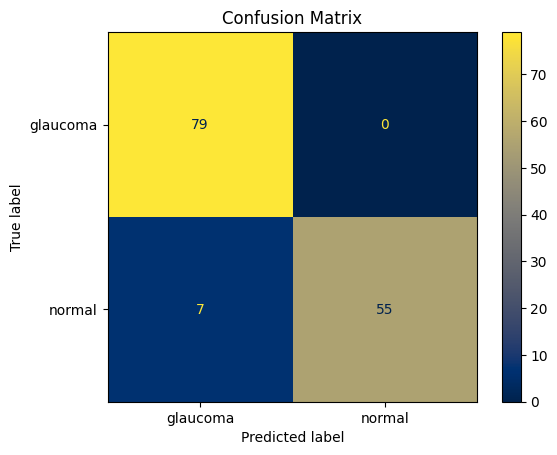

In [37]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Function to get predictions and labels
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    return all_preds, all_labels, all_probs

# Get predictions and labels for the test set
test_preds, test_labels, test_probs = get_predictions_and_labels(model, test_loader, device)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.cividis)
plt.title('Confusion Matrix')
plt.show()

# Binarize the labels for ROC-AUC curve
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

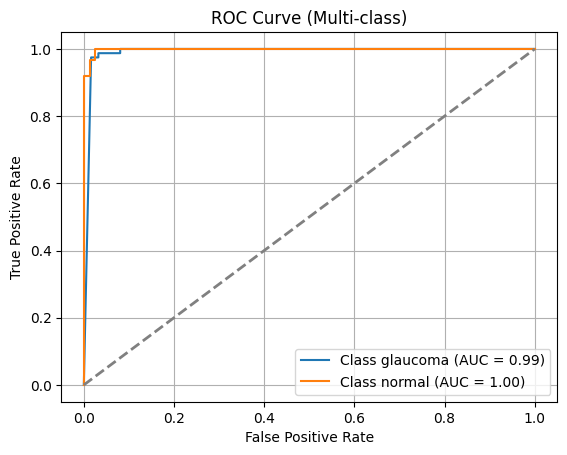

In [38]:
# 12. ROC Curve (Multi-Class)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true = np.eye(num_classes)[test_labels]  # one-hot encode

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i],np.array(test_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ["blue", "green", "red", "orange"]
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [39]:
# Calculate precision, recall, specificity, and accuracy
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

precision = TP / (TP + FP)
specificity = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
F1score = (2*TP) /(2*TP + FP + FN);


# Calculate overall metrics
overall_precision = np.mean(precision)
overall_specificity = np.mean(specificity)
overall_accuracy = np.mean(accuracy)
overall_recall = np.mean(recall)
overall_F1score =np.mean(F1score)

# Binarize the labels for ROC-AUC curve
num_classes = len(full_dataset.classes)
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

# Print overall metrics
print("Overall Metrics:")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall (Sensitivity): {overall_recall:.4f}")
print(f"  Specificity: {overall_specificity:.4f}")
print(f"  Accuracy: {overall_accuracy:.4f}")
print(f"  F1score: {overall_F1score:.4f}")

Overall Metrics:
  Precision: 0.9593
  Recall (Sensitivity): 0.9435
  Specificity: 0.9435
  Accuracy: 0.9504
  F1score: 0.9489


In [40]:
# Define the CKAN_Multi_Classification model
class CKAN_Multi_Classification(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CKAN_Multi_Classification, self).__init__()
        self.conv1 = KAN_Convolution(
            in_channels=in_channels,
            out_channels=16,
            kernel_size=(3, 3)
        )

        self.bn1 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = KAN_Convolution(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.kan1 = KANLinear(32 * 54 * 54, 256)
        self.kan2 = KANLinear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.kan1(x)
        x = self.kan2(x)
        x = F.log_softmax(x, dim=1)
        return x

Epoch 1/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.87it/s]


Epoch [1/50], Train Loss: 6.1682, Validation Loss: 0.5299
Train Accuracy: 0.6241, Validation Accuracy: 0.7143
Train Precision: 0.6191, Recall: 0.5995, F1: 0.5938
Validation Precision: 0.8261, Recall: 0.6923, F1: 0.6725


Epoch 2/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.89it/s]


Epoch [2/50], Train Loss: 0.3368, Validation Loss: 0.7036
Train Accuracy: 0.8511, Validation Accuracy: 0.8036
Train Precision: 0.8485, Recall: 0.8523, F1: 0.8497
Validation Precision: 0.8659, Recall: 0.7885, F1: 0.7884


Epoch 3/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.63it/s]


...

Epoch [48/50], Train Loss: 0.0230, Validation Loss: 0.0350
Train Accuracy: 0.9947, Validation Accuracy: 0.9821
Train Precision: 0.9948, Recall: 0.9944, F1: 0.9946
Validation Precision: 0.9839, Recall: 0.9808, F1: 0.9820


Epoch 49/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.85it/s]


Epoch [49/50], Train Loss: 0.0154, Validation Loss: 0.0024
Train Accuracy: 0.9929, Validation Accuracy: 1.0000
Train Precision: 0.9928, Recall: 0.9928, F1: 0.9928
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000


Epoch 50/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.87it/s]


Epoch [50/50], Train Loss: 0.0114, Validation Loss: 0.0017
Train Accuracy: 0.9965, Validation Accuracy: 1.0000
Train Precision: 0.9969, Recall: 0.9960, F1: 0.9964
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Early stopping triggered!


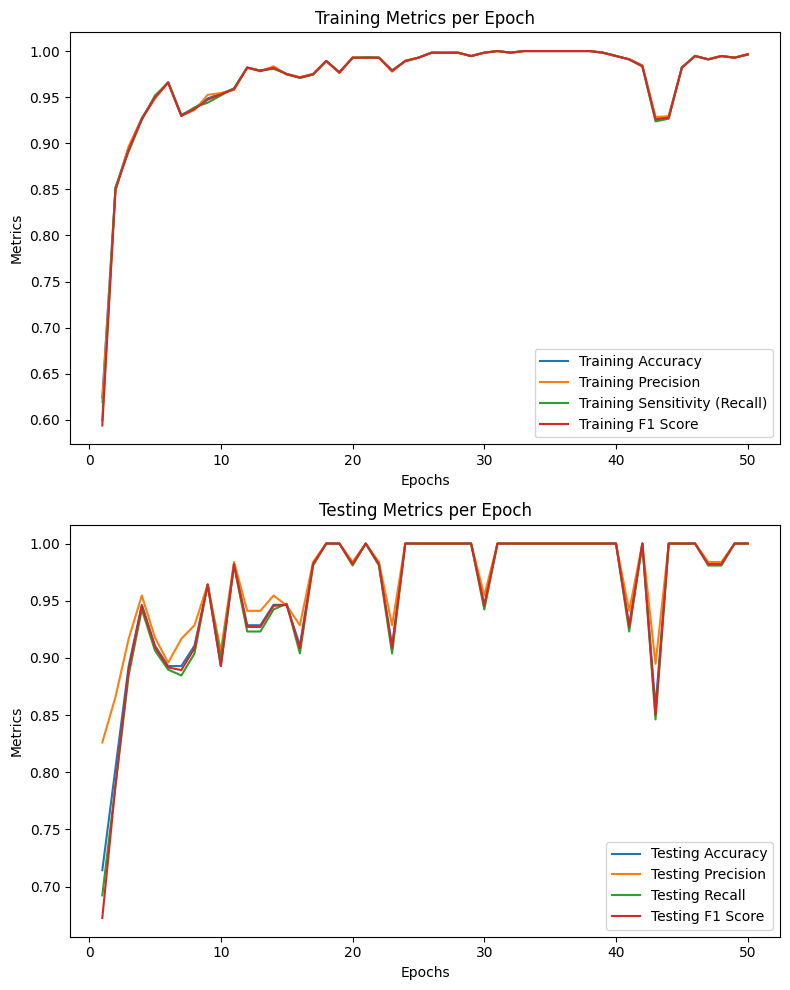

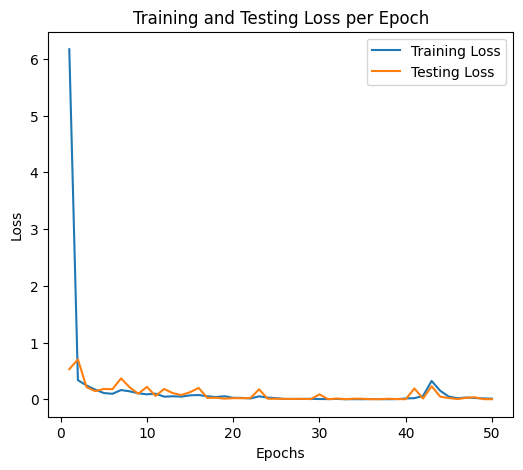

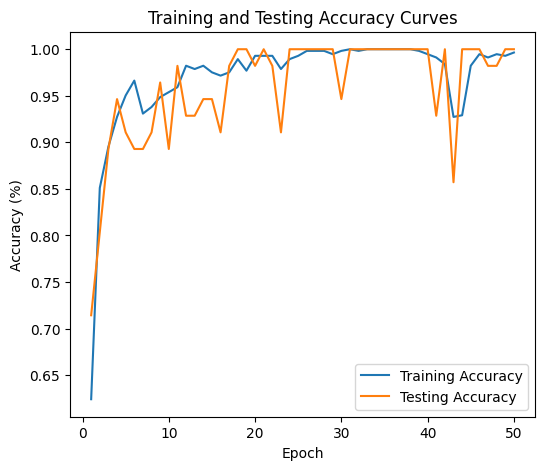

Training time: 678.85 seconds


In [41]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
import time

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
#model = KANC_MLP().to(device)          
model = CKAN_Multi_Classification(num_classes=num_classes,in_channels= 3 ).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

start_time = time.time()

# Training loop with early stopping
num_epochs = 50
patience = 10  # Stop if validation loss does not decrease for 5 consecutive epochs
best_val_loss = np.inf
counter = 0

# Lists to store losses and metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Additional metric lists for precision, recall (sensitivity), specificity, and F1
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1s = []
val_f1s = []
train_specificities = []
val_specificities = []

# Function to calculate specificity
#def specificity_score(y_true, y_pred):
 #   cm = confusion_matrix(y_true, y_pred)
  #  tn, fp, fn, tp = cm.ravel()
   # return tn / (tn + fp)

for epoch in range(num_epochs):
    # Training code
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    all_train_preds = []
    all_train_labels = []
    model.train()
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Store predictions and true labels for metrics calculation
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Calculate metrics for training
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy =  correct_train / total_train
    train_precision = precision_score(all_train_labels, all_train_preds, average='macro', zero_division=1)
    train_recall = recall_score(all_train_labels, all_train_preds, average='macro')
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
    #train_specificity = specificity_score(all_train_labels, all_train_preds,average='macro')

    # Store metrics for training
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)
    #train_specificities.append(train_specificity)

    # Validation code
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_val_preds = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Store predictions and true labels for metrics calculation
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    # Calculate metrics for validation
    val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=1)
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro')
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
    #val_specificity = specificity_score(all_val_labels, all_val_preds,average='macro')

    # Store metrics for validation
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    #val_specificities.append(val_specificity)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Plotting the metrics curves
epochs_range = range(1, len(train_losses) + 1)

# Plot metrics for Training
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, train_precisions, label='Training Precision')
plt.plot(epochs_range, train_recalls, label='Training Sensitivity (Recall)')
plt.plot(epochs_range, train_f1s, label='Training F1 Score')
#plt.plot(epochs_range, train_specificities, label='Training Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training Metrics per Epoch')
plt.legend()

# Plot metrics for Validation
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, label='Testing Accuracy')
plt.plot(epochs_range, val_precisions, label='Testing Precision')
plt.plot(epochs_range, val_recalls, label='Testing Recall')
plt.plot(epochs_range, val_f1s, label='Testing F1 Score')
#plt.plot(epochs_range, val_specificities, label='Validation Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Testing Metrics per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Loss curves
plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss per Epoch')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs_range,train_accuracies, label='Training Accuracy')
plt.plot(epochs_range,val_accuracies, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy Curves')
plt.legend()

plt.show()

end_time = time.time()

training_time = end_time - start_time  # Calculate testing time
print(f"Training time: {training_time:.2f} seconds")

<Figure size 1000x800 with 0 Axes>

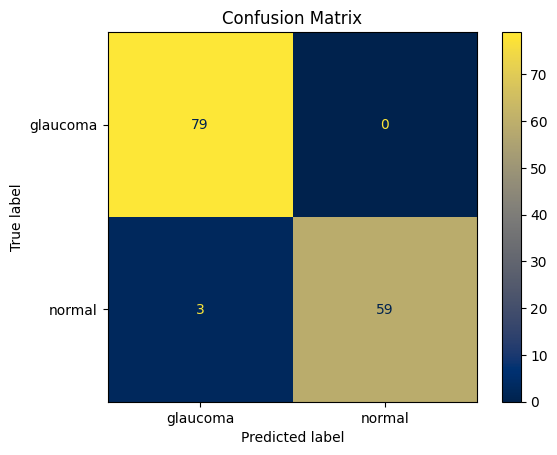

In [42]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Function to get predictions and labels
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    return all_preds, all_labels, all_probs

# Get predictions and labels for the test set
test_preds, test_labels, test_probs = get_predictions_and_labels(model, test_loader, device)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.cividis)
plt.title('Confusion Matrix')
plt.show()

# Binarize the labels for ROC-AUC curve
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))


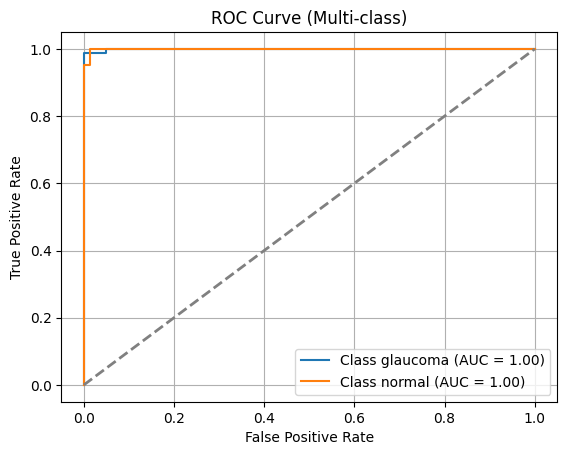

In [43]:
# 12. ROC Curve (Multi-Class)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true = np.eye(num_classes)[test_labels]  # one-hot encode

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i],np.array(test_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ["blue", "green", "red", "orange"]
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [44]:
# Calculate precision, recall, specificity, and accuracy
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

precision = TP / (TP + FP)
specificity = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
F1score = (2*TP) /(2*TP + FP + FN);


# Calculate overall metrics
overall_precision = np.mean(precision)
overall_specificity = np.mean(specificity)
overall_accuracy = np.mean(accuracy)
overall_recall = np.mean(recall)
overall_F1score =np.mean(F1score)

# Binarize the labels for ROC-AUC curve
num_classes = len(full_dataset.classes)
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

# Print overall metrics
print("Overall Metrics:")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall (Sensitivity): {overall_recall:.4f}")
print(f"  Specificity: {overall_specificity:.4f}")
print(f"  Accuracy: {overall_accuracy:.4f}")
print(f"  F1score: {overall_F1score:.4f}")

Overall Metrics:
  Precision: 0.9817
  Recall (Sensitivity): 0.9758
  Specificity: 0.9758
  Accuracy: 0.9787
  F1score: 0.9783


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CKAN_Multi_Classification(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super(CKAN_Multi_Classification, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=16,
            kernel_size=(3, 3)
        )

        self.bn1 = nn.BatchNorm2d(16)

        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=(3, 3)
        )
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.kan1 = KANLinear(32 * 54 * 54, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)

        x = self.kan1(x)
        return x

Epoch 1/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.88it/s]


Epoch [1/50], Train Loss: 2.6688, Validation Loss: 0.4173
Train Accuracy: 0.8156, Validation Accuracy: 0.8929
Train Precision: 0.8128, Recall: 0.8163, F1: 0.8139
Validation Precision: 0.9037, Recall: 0.8872, F1: 0.8906


Epoch 2/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.05it/s]


Epoch [2/50], Train Loss: 0.8717, Validation Loss: 1.3148
Train Accuracy: 0.9397, Validation Accuracy: 0.8929
Train Precision: 0.9400, Recall: 0.9374, F1: 0.9386
Validation Precision: 0.8929, Recall: 0.8949, F1: 0.8927


Epoch 3/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.04it/s]


...

Epoch [34/50], Train Loss: 0.0361, Validation Loss: 0.0000
Train Accuracy: 0.9947, Validation Accuracy: 1.0000
Train Precision: 0.9944, Recall: 0.9948, F1: 0.9946
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000


Epoch 35/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  5.06it/s]


Epoch [35/50], Train Loss: 0.0084, Validation Loss: 0.0002
Train Accuracy: 0.9982, Validation Accuracy: 1.0000
Train Precision: 0.9984, Recall: 0.9980, F1: 0.9982
Validation Precision: 1.0000, Recall: 1.0000, F1: 1.0000


Epoch 36/50: Validation: 100%|██████████| 2/2 [00:00<00:00,  4.22it/s]


Epoch [36/50], Train Loss: 0.0769, Validation Loss: 1.6809
Train Accuracy: 0.9929, Validation Accuracy: 0.9107
Train Precision: 0.9928, Recall: 0.9928, F1: 0.9928
Validation Precision: 0.9116, Recall: 0.9090, F1: 0.9100
Early stopping triggered!


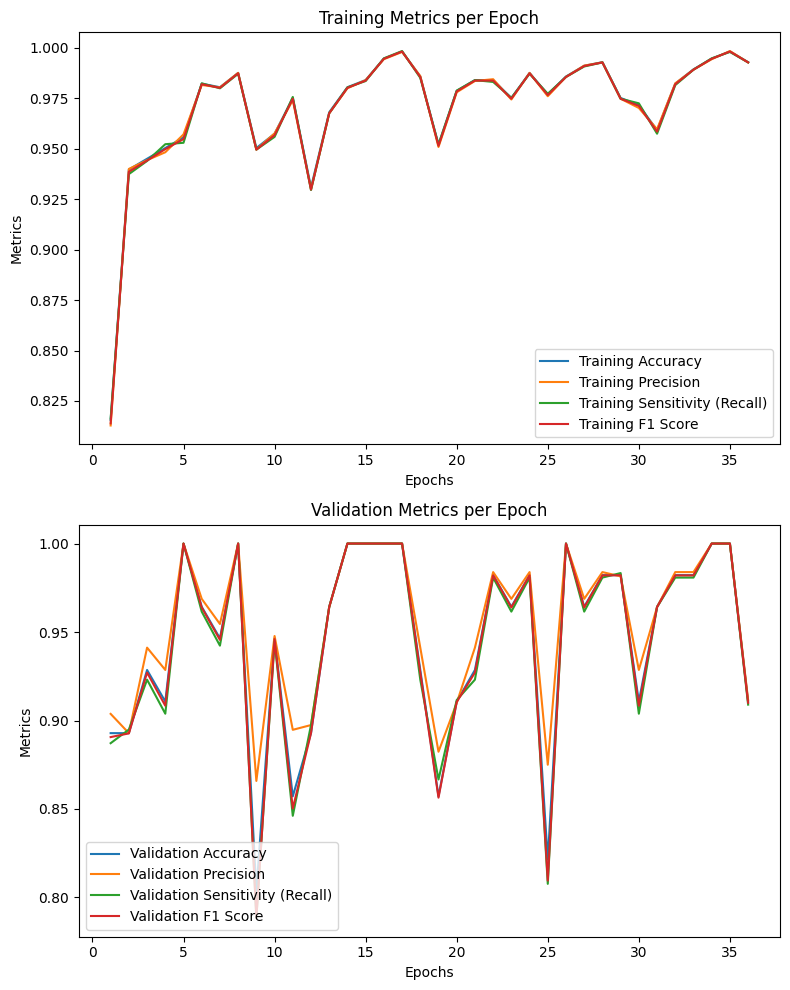

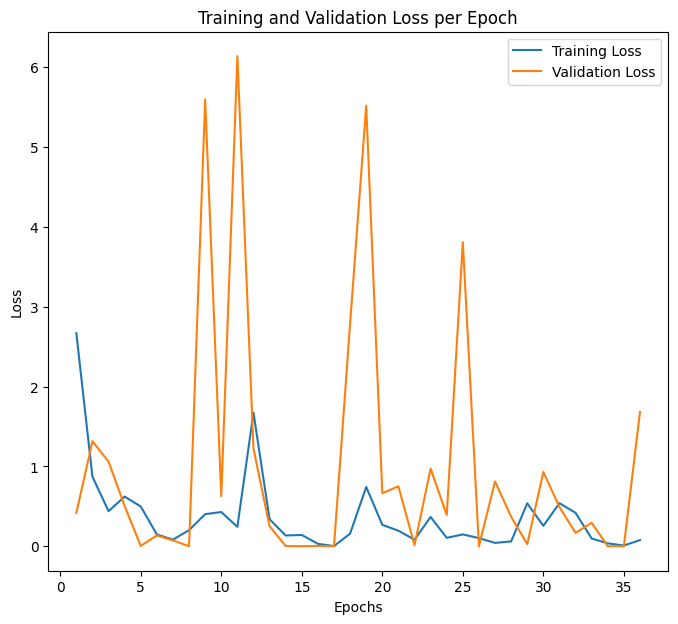

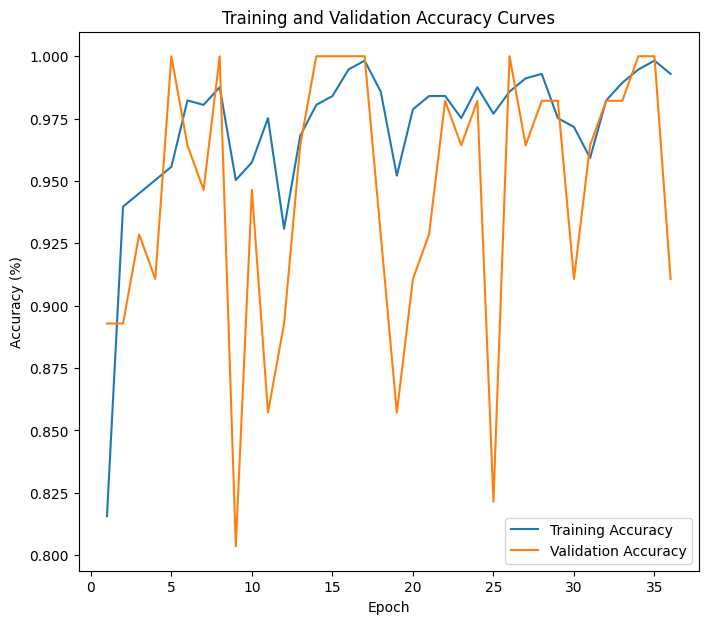

In [46]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
model = CKAN_Multi_Classification(num_classes=num_classes, in_channels=3).to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training loop with early stopping
num_epochs = 50
patience = 10  # Stop if validation loss does not decrease for 5 consecutive epochs
best_val_loss = np.inf
counter = 0

# Lists to store losses and metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Additional metric lists for precision, recall (sensitivity), specificity, and F1
train_precisions = []
val_precisions = []
train_recalls = []
val_recalls = []
train_f1s = []
val_f1s = []
train_specificities = []
val_specificities = []

# Function to calculate specificity
#def specificity_score(y_true, y_pred):
 #   cm = confusion_matrix(y_true, y_pred)
  #  tn, fp, fn, tp = cm.ravel()
   # return tn / (tn + fp)

for epoch in range(num_epochs):
    # Training code
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    all_train_preds = []
    all_train_labels = []
    model.train()
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Training'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Store predictions and true labels for metrics calculation
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # Calculate metrics for training
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy =  correct_train / total_train
    train_precision = precision_score(all_train_labels, all_train_preds, average='macro', zero_division=1)
    train_recall = recall_score(all_train_labels, all_train_preds, average='macro')
    train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
    #train_specificity = specificity_score(all_train_labels, all_train_preds,average='macro')

    # Store metrics for training
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)
    #train_specificities.append(train_specificity)

    # Validation code
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_val_preds = []
    all_val_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs}: Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            # Store predictions and true labels for metrics calculation
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    # Calculate metrics for validation
    val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_precision = precision_score(all_val_labels, all_val_preds, average='macro', zero_division=1)
    val_recall = recall_score(all_val_labels, all_val_preds, average='macro')
    val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
    #val_specificity = specificity_score(all_val_labels, all_val_preds,average='macro')

    # Store metrics for validation
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    #val_specificities.append(val_specificity)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
    print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# Plotting the metrics curves
epochs_range = range(1, len(train_losses) + 1)

# Plot metrics for Training
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, train_precisions, label='Training Precision')
plt.plot(epochs_range, train_recalls, label='Training Sensitivity (Recall)')
plt.plot(epochs_range, train_f1s, label='Training F1 Score')
#plt.plot(epochs_range, train_specificities, label='Training Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Training Metrics per Epoch')
plt.legend()

# Plot metrics for Validation
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.plot(epochs_range, val_precisions, label='Validation Precision')
plt.plot(epochs_range, val_recalls, label='Validation Sensitivity (Recall)')
plt.plot(epochs_range, val_f1s, label='Validation F1 Score')
#plt.plot(epochs_range, val_specificities, label='Validation Specificity')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.title('Validation Metrics per Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Loss curves
plt.figure(figsize=(8, 7))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 7))
plt.plot(epochs_range,train_accuracies, label='Training Accuracy')
plt.plot(epochs_range,val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Curves')
plt.legend()

plt.show()

<Figure size 1000x800 with 0 Axes>

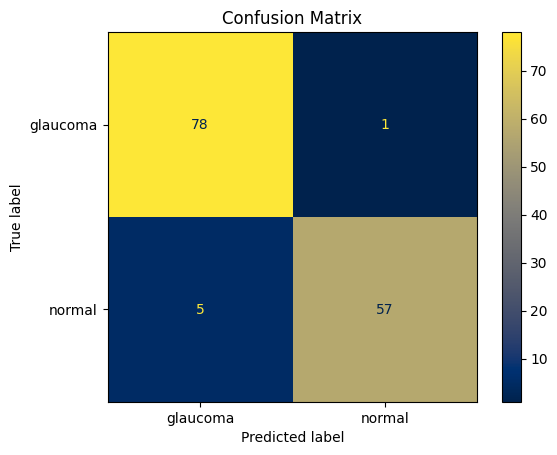

In [47]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# Function to get predictions and labels
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
    return all_preds, all_labels, all_probs

# Get predictions and labels for the test set
test_preds, test_labels, test_probs = get_predictions_and_labels(model, test_loader, device)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.cividis)
plt.title('Confusion Matrix')
plt.show()

# Binarize the labels for ROC-AUC curve
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))

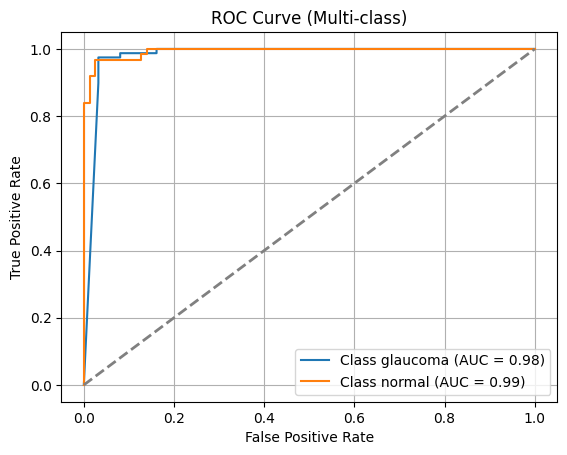

In [48]:
# 12. ROC Curve (Multi-Class)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_true = np.eye(num_classes)[test_labels]  # one-hot encode

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i],np.array(test_probs)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
colors = ["blue", "green", "red", "orange"]
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {full_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [49]:
# Calculate precision, recall, specificity, and accuracy
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

precision = TP / (TP + FP)
specificity = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
recall = TP / (TP + FN)
F1score = (2*TP) /(2*TP + FP + FN);


# Calculate overall metrics
overall_precision = np.mean(precision)
overall_specificity = np.mean(specificity)
overall_accuracy = np.mean(accuracy)
overall_recall = np.mean(recall)
overall_F1score =np.mean(F1score)

# Binarize the labels for ROC-AUC curve
num_classes = len(full_dataset.classes)
test_labels_binarized = label_binarize(test_labels, classes=list(range(num_classes)))



# Print overall metrics
print("Overall Metrics:")
print(f"  Precision: {overall_precision:.4f}")
print(f"  Recall (Sensitivity): {overall_recall:.4f}")
print(f"  Specificity: {overall_specificity:.4f}")
print(f"  Accuracy: {overall_accuracy:.4f}")
print(f"  F1score: {overall_F1score:.4f}")

Overall Metrics:
  Precision: 0.9613
  Recall (Sensitivity): 0.9533
  Specificity: 0.9533
  Accuracy: 0.9574
  F1score: 0.9565


In [50]:
class_names = full_dataset.classes

print("Classes:", class_names)

def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    img = (img - img.min()) / (img.max())  # normalize
    plt.imshow(img)
    plt.axis("off")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import torch

def test_and_show_samples(num_samples):
    model.eval()
    shown = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img, label in test_loader:

            batch_size = img.size(0)

            for i in range(batch_size):

                if shown >= num_samples:
                    break

                image_tensor = img[i].unsqueeze(0).to(device)
                outputs = model(image_tensor)
                probs = torch.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)

                # Save for confusion matrix later
                all_preds.append(pred.item())
                all_labels.append(label[i].item())

                # -----------------------------
                # PLOT 1: Image with prediction
                # -----------------------------
                plt.figure(figsize=(5, 5))
                plt.title(
                    f"True: {class_names[label[i].item()]}\n"
                    f"Pred: {class_names[pred.item()]} ({probs[0][pred.item()].item()*100:.1f}%)"
                )
                imshow(img[i])
                plt.show()

                # -----------------------------
                # PLOT 2: Probability bar plot
                # -----------------------------
                plt.figure(figsize=(6, 3))
                plt.bar(class_names, probs.cpu().numpy()[0])
                plt.ylabel("Probability")
                plt.title("Prediction Probabilities")
                plt.xticks(rotation=45)
                plt.ylim(0, 1)
                plt.show()

                shown += 1

    # ---------------------------------------------------
    # After showing samples → print Confusion Matrix & Report
    # ---------------------------------------------------
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

Classes: ['glaucoma', 'normal']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


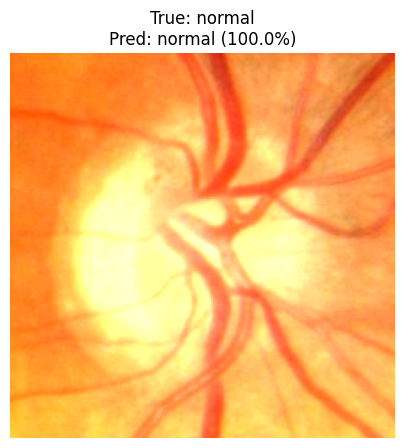

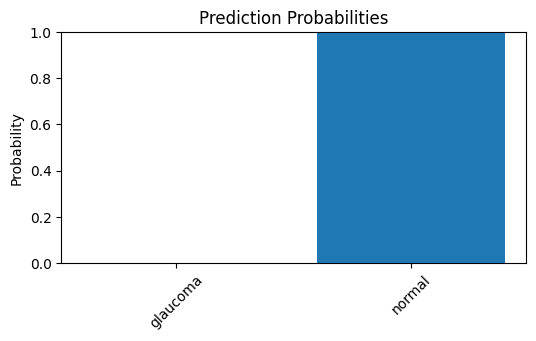

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


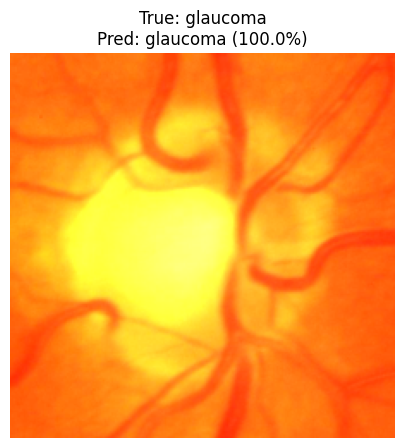

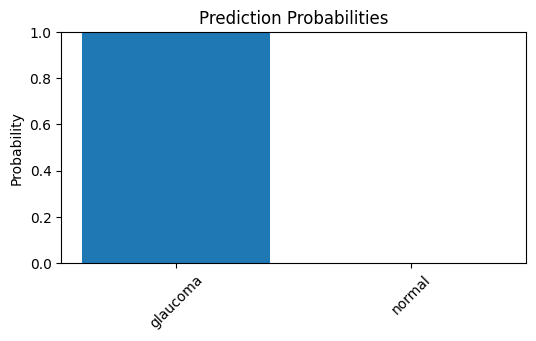

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


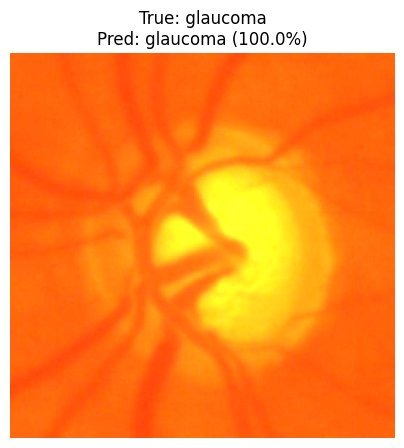

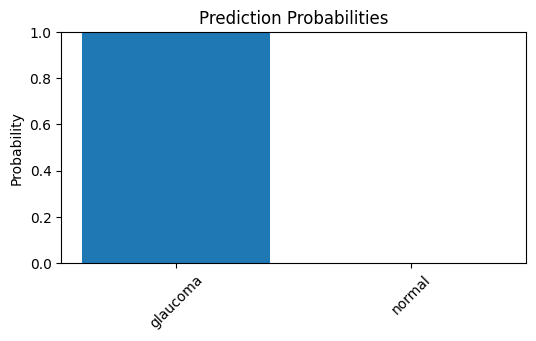

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


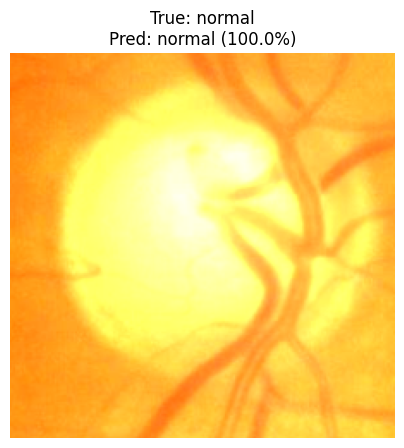

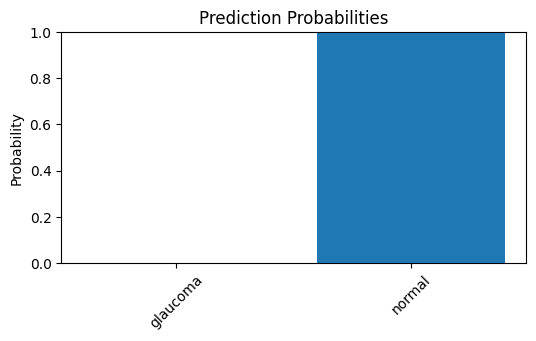

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


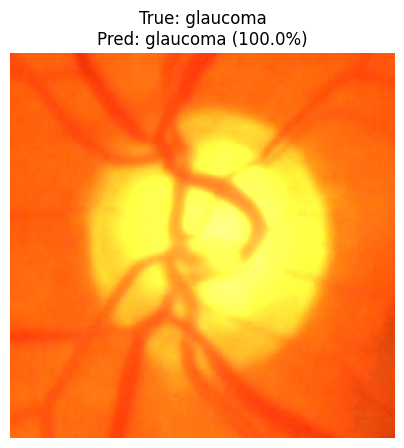

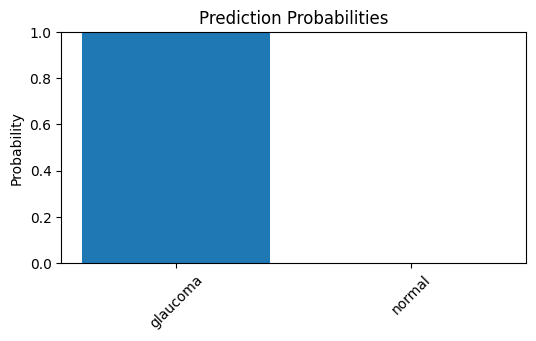

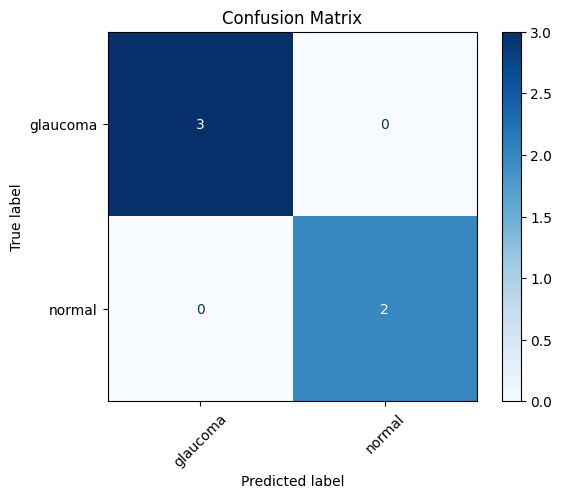


Classification Report

              precision    recall  f1-score   support

    glaucoma       1.00      1.00      1.00         3
      normal       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [53]:
test_and_show_samples(5)

In [54]:
import torch
import pickle

# Save the trained model
def save_model(model, path='glaucoma_model.pth'):
    """Save the trained model state"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_architecture': 'CKAN_Multi_Classification',
        'num_classes': 2,
        'class_names': ['glaucoma', 'normal']
    }, path)
    print(f"✓ Model saved to {path}")

# Save model
save_model(model, 'glaucoma_kan_model.pth')

# Save the complete model architecture info
model_info = {
    'input_size': (224, 224),
    'num_classes': 2,
    'class_names': ['glaucoma', 'normal'],
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225],
    'model_type': 'CNN_with_KAN'
}

with open('model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
    
print("✓ Model info saved to model_info.pkl")

# Save preprocessing transforms info
preprocessing_info = {
    'resize': 256,
    'crop': 224,
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225]
}

with open('preprocessing_info.pkl', 'wb') as f:
    pickle.dump(preprocessing_info, f)
    
print("✓ Preprocessing info saved to preprocessing_info.pkl")

# List saved files
import os
print("\n" + "="*50)
print("SAVED FILES:")
print("="*50)
for file in ['glaucoma_kan_model.pth', 'model_info.pkl', 'preprocessing_info.pkl']:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024*1024)  # Convert to MB
        print(f"  ✓ {file} ({size:.2f} MB)")
print("="*50)
print("\nYou can now download these files for deployment!")

✓ Model saved to glaucoma_kan_model.pth
✓ Model info saved to model_info.pkl
✓ Preprocessing info saved to preprocessing_info.pkl

SAVED FILES:
  ✓ glaucoma_kan_model.pth (11.42 MB)
  ✓ model_info.pkl (0.00 MB)
  ✓ preprocessing_info.pkl (0.00 MB)

You can now download these files for deployment!
